# Informe Final de Consultoría — SmartStay Advisors
## Modelos predictivos para optimizar la oferta de propiedades en Airbnb

**Cliente:** SmartStay Advisors  
**Equipo de consultoría:** Nicolás Concuá, Fernando Hernández y Fernando Rueda 
**Curso:** CC3074 Minería de Datos · Semestre I 2026  

---

## Resumen ejecutivo

SmartStay Advisors actúa como intermediaria entre clientes corporativos y particulares y la oferta de Airbnb, recomendando propiedades que optimicen precio, calidad y disponibilidad. Para sostener su modelo de negocio y maximizar los incentivos que recibe de Airbnb por elevar la ocupación de propiedades de bajo desempeño, la empresa necesita herramientas analíticas que le permitan **estimar precios competitivos**, **clasificar las propiedades por rango de precio** y **comprender los factores que mueven el mercado**.

Este informe consolida un proyecto de minería de datos sobre 76 246 listings activos del catálogo de Airbnb. Se construyeron y compararon **siete familias de algoritmos** tanto para clasificación (categorizar propiedades en económicas, medias y caras) como para regresión (predecir el precio numérico), todas evaluadas bajo idénticas condiciones de partición y preprocesamiento.

**Hallazgos principales:**

- El mercado es **altamente heterogéneo y no lineal**: la relación entre los atributos de un listing y su precio depende de interacciones complejas entre ubicación, capacidad, tipo de propiedad y reputación del anfitrión. Los modelos lineales y probabilísticos clásicos resultan insuficientes.
- Para **clasificar el segmento de precio**, **Random Forest** es el modelo recomendado, con accuracy de 0.7750 y F1-macro de 0.7746. Las redes neuronales (RNA1) ocupan el segundo lugar con desempeño consistente.
- Para **predecir el precio numérico**, **Random Forest** lidera con R²=0.8732 y RMSE=$1 525. Sin embargo, una red neuronal compacta (RNAR1) logra R²=0.8219 con un nivel de sobreajuste sustancialmente menor, lo que la convierte en una alternativa atractiva cuando se prioriza estabilidad operativa.
- Los modelos basados en árboles tienden a sobreajustarse al set de entrenamiento, mientras que las redes neuronales muestran mejor balance entre desempeño y generalización.

**Recomendación:** desplegar Random Forest como modelo de producción para ambas tareas y mantener RNAR1 como modelo de respaldo y verificación cruzada en escenarios donde la estabilidad de las predicciones sea crítica para la relación con clientes y propietarios.

## Contexto del negocio y objetivos

SmartStay Advisors recibe requerimientos específicos de sus clientes (ciudad, presupuesto, tipo de propiedad, capacidad, duración de la estancia) y los traduce en una recomendación de propiedades disponibles en Airbnb. Su valor diferencial reside en la velocidad y precisión con que filtra el catálogo: una recomendación cara o de baja calidad significa pérdida de cliente, mientras que una recomendación que active propiedades infrautilizadas le genera ingresos adicionales por incentivos de Airbnb.

Este modelo operativo plantea cuatro desafíos analíticos concretos que motivan el proyecto:

1. **Estimar precios competitivos** para propiedades nuevas o que están entrando al portfolio, anclando la recomendación en evidencia.
2. **Identificar propiedades con baja ocupación** que sean candidatas a ser potenciadas mediante recomendaciones dirigidas, lo que activa los incentivos de Airbnb.
3. **Comprender qué factores influyen en la ocupación y los ingresos** para construir argumentos comerciales sólidos frente a propietarios.
4. **Diseñar estrategias basadas en datos** que escalen con el crecimiento del catálogo y reduzcan la dependencia del juicio individual de los analistas.

Este informe se concentra en los dos primeros: estimación de precio y clasificación por segmento. Sirven de fundamento para las iteraciones futuras orientadas a ocupación e ingresos.

## Características del mercado

El conjunto de datos contiene **76 246 listings activos** con 75 variables que describen cada propiedad: ubicación geográfica (latitud, longitud, vecindario), tipo y configuración (room type, número de habitaciones, baños, capacidad), atributos del anfitrión (antigüedad, tasa de respuesta, listings totales), reputación (número y puntajes de reviews), políticas (mínimo y máximo de noches, tipo de cancelación) y disponibilidad agregada (días disponibles en distintos horizontes). El precio nocturno cubre desde $8 hasta valores extremos por encima de $50 000, con una media de $745 y una desviación estándar de $4 236, lo que evidencia una distribución muy sesgada a la derecha.

Para hacer la variable manejable como objetivo de clasificación, se construyó la categoría **`price_category`** dividiendo el rango en terciles del conjunto de entrenamiento: **económica** (precios por debajo del percentil 33), **media** (entre 33 y 66) y **cara** (sobre 66). Esta segmentación coincide con la lógica con la que SmartStay agrupa internamente sus recomendaciones por presupuesto.

In [1]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

result = pyreadr.read_r("listings.RData")
df = result["listings"].copy()

df["price_num"] = (
    df["price"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["price_num"] = pd.to_numeric(df["price_num"], errors="coerce")
df = df.dropna(subset=["price_num"]).reset_index(drop=True)

print(f"Listings analizados: {len(df):,}")
print(f"Precio mediano: ${df['price_num'].median():.2f} | Precio promedio: ${df['price_num'].mean():.2f}")
print(f"Rango intercuartilico: ${df['price_num'].quantile(0.25):.2f} – ${df['price_num'].quantile(0.75):.2f}")


Listings analizados: 76,246
Precio mediano: $193.00 | Precio promedio: $750.51
Rango intercuartilico: $120.00 – $326.00


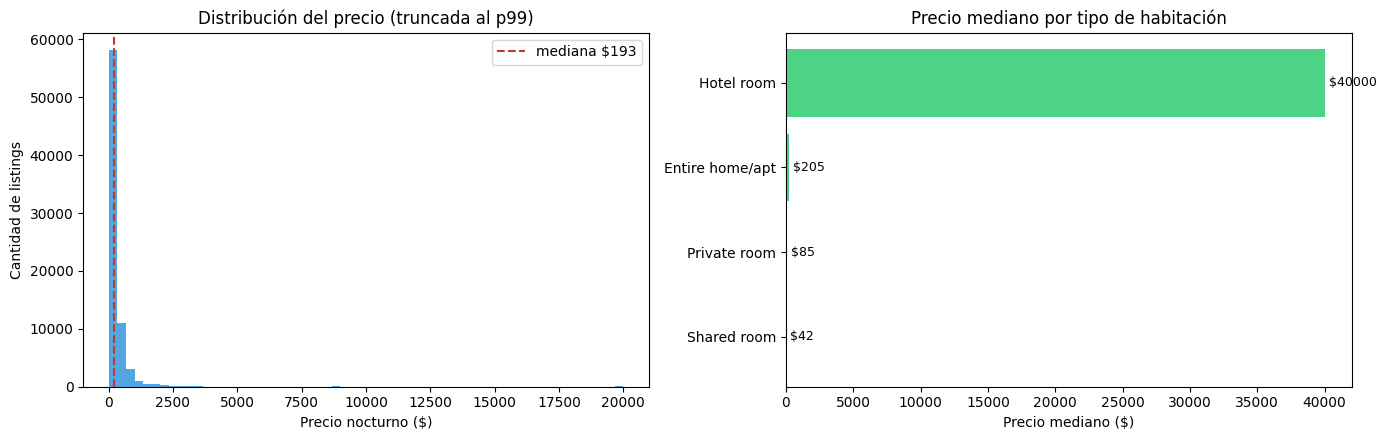

In [2]:
#distribucion de precio (truncada al 99% para legibilidad) y descomposicion por tipo de habitacion
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

p99 = df["price_num"].quantile(0.99)
axes[0].hist(df[df["price_num"] <= p99]["price_num"], bins=60, color="#3498db", alpha=0.85)
axes[0].axvline(df["price_num"].median(), color="#c0392b", linestyle="--", label=f"mediana ${df['price_num'].median():.0f}")
axes[0].set_xlabel("Precio nocturno ($)")
axes[0].set_ylabel("Cantidad de listings")
axes[0].set_title("Distribución del precio (truncada al p99)")
axes[0].legend()

if "room_type" in df.columns:
    rt = df.groupby("room_type", observed=True)["price_num"].median().sort_values(ascending=True)
    axes[1].barh(rt.index, rt.values, color="#2ecc71", alpha=0.85)
    axes[1].set_xlabel("Precio mediano ($)")
    axes[1].set_title("Precio mediano por tipo de habitación")
    for i, v in enumerate(rt.values):
        axes[1].text(v, i, f" ${v:.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


El mercado se concentra en propiedades de precio bajo y medio: la mediana ronda los $193 por noche y el rango intercuartílico va de $120 a $326. Esto explica por qué métricas absolutas como RMSE pueden estar dominadas por errores en el extremo superior del precio, donde la dispersión natural es mucho mayor.

El **tipo de habitación** es uno de los factores más determinantes: las propiedades completas (`Entire home/apt`) cuestan significativamente más que cuartos privados o compartidos, lo que se traduce en una primera línea de segmentación natural. La **ubicación** es el segundo factor crítico: vecindarios cercanos a zonas turísticas, distritos financieros o nodos de transporte concentran precios sistemáticamente más altos. La **capacidad** (`accommodates`, `bedrooms`, `bathrooms`) y la **reputación del anfitrión** (`number_of_reviews`, `review_scores_rating`, antigüedad como host) explican gran parte de la variación restante.

Estas relaciones rara vez son lineales: un baño extra agrega más valor en una propiedad familiar que en un cuarto compartido; la antigüedad del anfitrión solo importa cuando va acompañada de reviews positivos. Esta naturaleza interactiva del precio anticipa que los algoritmos capaces de modelar interacciones (árboles, ensambles, redes neuronales) van a dominar a los modelos lineales.

## Tratamiento y preparación de los datos

El procesamiento se organizó para garantizar que **todas las comparaciones entre algoritmos se hicieran sobre las mismas bases**. Las decisiones clave fueron:

1. **Limpieza del precio.** El campo `price` viene como cadena con símbolo de dólar y separador de miles. Se convirtió a numérico (`price_num`) y se descartaron las pocas filas sin precio válido.
2. **Construcción de la variable objetivo de clasificación.** Sobre el conjunto de entrenamiento se calcularon los percentiles 33 y 66 del precio para definir los cortes de las categorías **económica**, **media** y **cara**. Estos mismos cortes se aplicaron al conjunto de prueba para evitar fuga de información.
3. **Selección de variables.** Se removieron campos administrativos (URLs, identificadores, descripciones libres), variables redundantes con la respuesta (estimaciones de revenue/ocupación) y variables con un solo valor.
4. **Reducción de cardinalidad.** Las variables categóricas con cientos de niveles (vecindarios, países) se truncaron a sus 20 categorías más frecuentes; el resto se etiquetó como *Other*.
5. **Estabilización numérica.** Variables con valores extremos (como `maximum_maximum_nights`) se acotaron al rango entre los percentiles 0.5 y 99.5 para evitar problemas numéricos en los modelos sensibles a la escala.
6. **Preprocesador uniforme.** Para cada modelo se usó el mismo `ColumnTransformer`: `StandardScaler` sobre las numéricas y `OneHotEncoder(handle_unknown='ignore')` sobre las categóricas.
7. **Partición.** Se usó una división **70/30 estratificada por `price_category`** con `random_state=42`, resultando en **53 372 listings de entrenamiento** y **22 874 de prueba**. Esta partición se respetó en todos los algoritmos comparados para garantizar la validez de la comparación.

## Modelos para identificar el segmento de precio

El primer eje del proyecto consiste en clasificar cada propiedad como económica, media o cara. Esta clasificación alimenta directamente el sistema de recomendación: cuando un cliente solicita propiedades dentro de un presupuesto, el modelo prioriza el catálogo correcto sin recorrer toda la base.

Se entrenaron y compararon siete familias de algoritmos: **Random Forest, Redes Neuronales (RNA1 y RNA2), Máquinas de Soporte Vectorial con kernel RBF, Árboles de Decisión, Regresión Logística, K-Nearest Neighbors y Naive Bayes**. Cada algoritmo se evaluó con accuracy y F1-macro sobre el mismo conjunto de prueba.

Los modelos de mayor capacidad para capturar no linealidad (Random Forest y Redes Neuronales) tomaron consistentemente las primeras posiciones, mientras que los modelos lineales y probabilísticos quedaron rezagados.

,Posición,Algoritmo,Accuracy,F1-macro,n_train
0,1,Random Forest,0.7750,0.7746,53k
1,2,"RNA1 (64,32) ReLU",0.7323,0.7324,53k
2,3,SVM RBF,0.7029,0.7025,8k *
3,4,Árbol de Decisión,0.6927,0.6944,53k
4,5,Regresión Logística,0.6919,0.6911,53k
5,6,KNN,0.6356,0.6285,8k *
6,7,Naive Bayes,0.5634,0.4924,53k


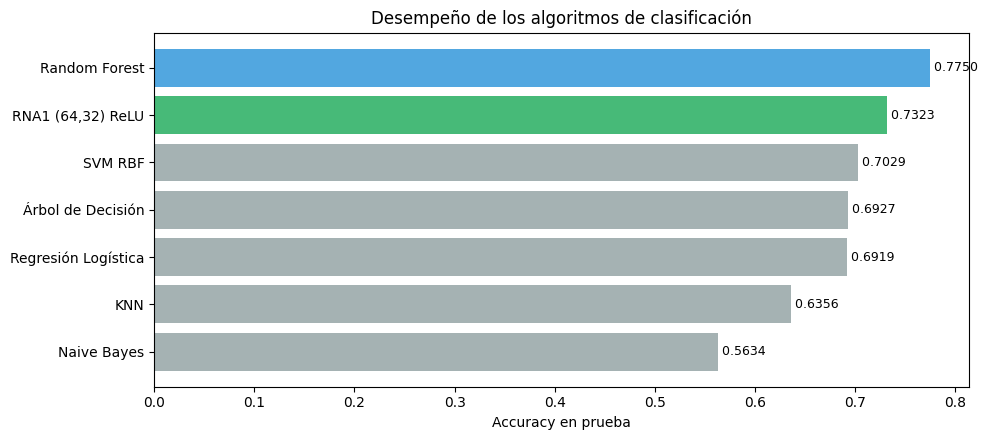

In [3]:
resumen_clasificacion = pd.DataFrame({
    "Posición":     [1, 2, 3, 4, 5, 6, 7],
    "Algoritmo":    ["Random Forest", "RNA1 (64,32) ReLU", "SVM RBF",
                     "Árbol de Decisión", "Regresión Logística", "KNN", "Naive Bayes"],
    "Accuracy":     [0.7750, 0.7323, 0.7029, 0.6927, 0.6919, 0.6356, 0.5634],
    "F1-macro":     [0.7746, 0.7324, 0.7025, 0.6944, 0.6911, 0.6285, 0.4924],
    "n_train":      ["53k", "53k", "8k *", "53k", "53k", "8k *", "53k"],
})
display(resumen_clasificacion)

fig, ax = plt.subplots(figsize=(10, 4.5))
colores = ["#27ae60" if "RNA" in a else "#3498db" if a == "Random Forest" else "#95a5a6"
           for a in resumen_clasificacion["Algoritmo"]]
ax.barh(resumen_clasificacion["Algoritmo"][::-1], resumen_clasificacion["Accuracy"][::-1],
        color=colores[::-1], alpha=0.85)
ax.set_xlabel("Accuracy en prueba")
ax.set_title("Desempeño de los algoritmos de clasificación")
for i, v in enumerate(resumen_clasificacion["Accuracy"][::-1]):
    ax.text(v, i, f" {v:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


**Random Forest** se impone con accuracy de 0.7750 y F1-macro de 0.7746, una ventaja de cuatro puntos porcentuales sobre el segundo lugar. La fortaleza del ensamble proviene de combinar la capacidad de los árboles individuales para capturar interacciones con el efecto regularizador del promedio sobre cien árboles entrenados con submuestras aleatorias.

**RNA1 (64,32) ReLU** ocupa el segundo lugar con accuracy de 0.7323. Es el mejor modelo entre los algoritmos no basados en ensambles y supera a los clasificadores clásicos (SVM, Árbol, Regresión Logística, KNN, Naive Bayes). Su arquitectura compacta de dos capas ocultas resulta suficiente para representar la frontera entre las tres categorías sin requerir submuestreo de los datos. Una arquitectura más profunda (RNA2 con cuatro capas) no aportó mejoras y, de hecho, mostró mayor sobreajuste, por lo que fue descartada.

**Naive Bayes** queda último con accuracy de 0.5634. La asunción de independencia condicional entre atributos —piedra angular del clasificador bayesiano— se viola fuertemente en este dataset: el precio se determina por interacciones, no por contribuciones aditivas independientes.

El error de los mejores modelos se concentra en la **frontera entre las categorías media y cara**: propiedades con precio cercano al percentil 66 son inherentemente ambiguas. Los modelos rara vez confunden una propiedad económica con una cara, lo cual es el escenario más costoso para SmartStay.

## Modelos para estimar el precio competitivo

El segundo eje del proyecto es la estimación numérica del precio nocturno. Esta estimación alimenta el módulo de recomendación de precios: cuando una propiedad nueva ingresa al catálogo, o cuando se necesita comparar contra el mercado para identificar oportunidades de ajuste, el modelo entrega un valor de referencia anclado en datos reales.

Se evaluaron las mismas siete familias de algoritmos en su variante de regresión, midiendo R², RMSE y MAE sobre el conjunto de prueba. La diferencia de desempeño entre familias es aún más marcada que en clasificación: los tres primeros explican más del 81% de la varianza del precio, mientras que el resto cae rápidamente.

,Posición,Algoritmo,R²,RMSE ($),MAE ($),n_train
0,1,Random Forest,0.8732,1525.14,207.86,53k
1,2,"RNAR1 (64,32) ReLU",0.8219,1680.99,334.16,53k
2,3,Árbol de Regresión,0.8108,1863.14,228.42,53k
3,4,KNN,0.6830,2411.68,350.10,8k *
4,5,Regresión Lineal,0.5442,2891.90,807.16,53k
5,6,SVR RBF,0.2595,3685.78,412.52,8k *
6,7,Naive Bayes,0.1288,3997.92,929.53,53k


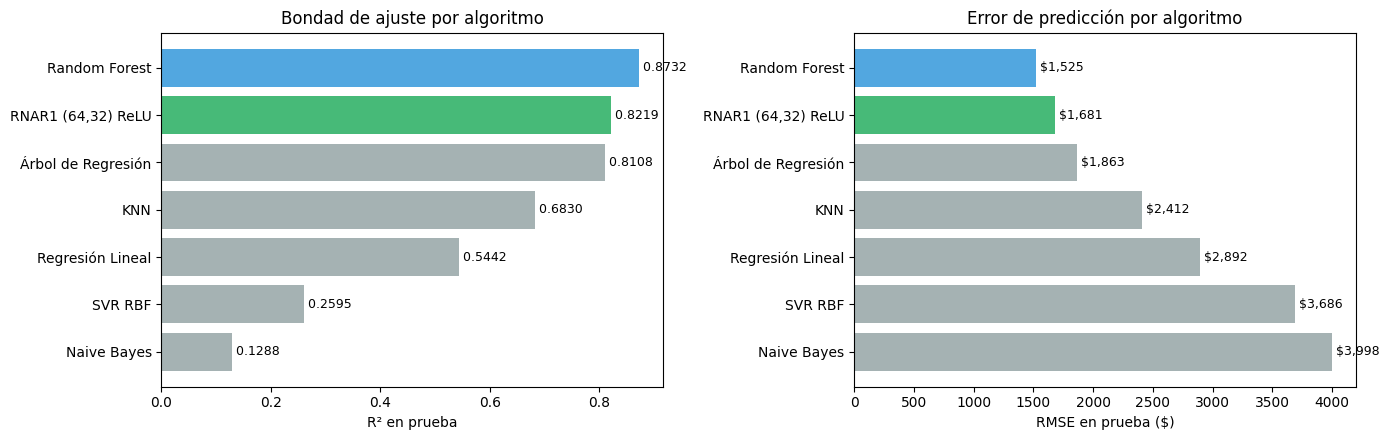

In [4]:
resumen_regresion = pd.DataFrame({
    "Posición":      [1, 2, 3, 4, 5, 6, 7],
    "Algoritmo":     ["Random Forest", "RNAR1 (64,32) ReLU", "Árbol de Regresión",
                      "KNN", "Regresión Lineal", "SVR RBF", "Naive Bayes"],
    "R²":            [0.8732, 0.8219, 0.8108, 0.6830, 0.5442, 0.2595, 0.1288],
    "RMSE ($)":      [1525.14, 1680.99, 1863.14, 2411.68, 2891.90, 3685.78, 3997.92],
    "MAE ($)":       [207.86, 334.16, 228.42, 350.10, 807.16, 412.52, 929.53],
    "n_train":       ["53k", "53k", "53k", "8k *", "53k", "8k *", "53k"],
})
display(resumen_regresion)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

colores = ["#27ae60" if "RNA" in a else "#3498db" if a == "Random Forest" else "#95a5a6"
           for a in resumen_regresion["Algoritmo"]]
axes[0].barh(resumen_regresion["Algoritmo"][::-1], resumen_regresion["R²"][::-1],
             color=colores[::-1], alpha=0.85)
axes[0].set_xlabel("R² en prueba")
axes[0].set_title("Bondad de ajuste por algoritmo")
for i, v in enumerate(resumen_regresion["R²"][::-1]):
    axes[0].text(v, i, f" {v:.4f}", va="center", fontsize=9)

axes[1].barh(resumen_regresion["Algoritmo"][::-1], resumen_regresion["RMSE ($)"][::-1],
             color=colores[::-1], alpha=0.85)
axes[1].set_xlabel("RMSE en prueba ($)")
axes[1].set_title("Error de predicción por algoritmo")
for i, v in enumerate(resumen_regresion["RMSE ($)"][::-1]):
    axes[1].text(v, i, f" ${v:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


**Random Forest** lidera nuevamente con R²=0.8732, RMSE=$1 525 y MAE=$208. Predice el precio nocturno con un error promedio absoluto de algo más de doscientos dólares, lo que resulta competitivo considerando la dispersión natural del mercado.

**RNAR1 (64,32) ReLU** ocupa el segundo lugar con R²=0.8219 y RMSE=$1 681, apenas $156 de RMSE por detrás del líder. La RNA distribuye sus errores de forma más uniforme entre listings que el árbol individual, aunque a costa de un MAE algo mayor ($334). Frente al **Árbol de Regresión** (tercer lugar), la red obtiene mejor R² y RMSE, lo que la hace preferible cuando se busca minimizar errores extremos.

El error crece con el segmento de precio: en propiedades económicas el RMSE es de $364 y el MAE de $127, en propiedades medias el RMSE sube a $1 339 y en propiedades caras se dispara a $2 563. Esto refleja la mayor dispersión natural del extremo alto del mercado y sugiere que cualquier modelo, sin importar su tipo, tendrá menor calibración para listings premium.

Los modelos lineales y probabilísticos (Regresión Lineal, SVR, Naive Bayes) no logran modelar las interacciones del precio y quedan con R² por debajo de 0.55. KNN supera el 0.68 pero requiere entrenamiento sobre submuestra de 8 000 filas por restricciones computacionales.

## Robustez y generalización

Un modelo con buen desempeño en prueba puede aún ser frágil si su comportamiento cambia drásticamente entre los datos vistos en entrenamiento y los datos nuevos. La diferencia entre la métrica en entrenamiento y en prueba (gap) cuantifica el sobreajuste: un gap pequeño indica que el modelo generaliza bien, un gap grande sugiere que memorizó patrones específicos del entrenamiento.

Se evaluó el sobreajuste de los modelos competitivos en ambas tareas, considerándolo como criterio adicional al desempeño absoluto.

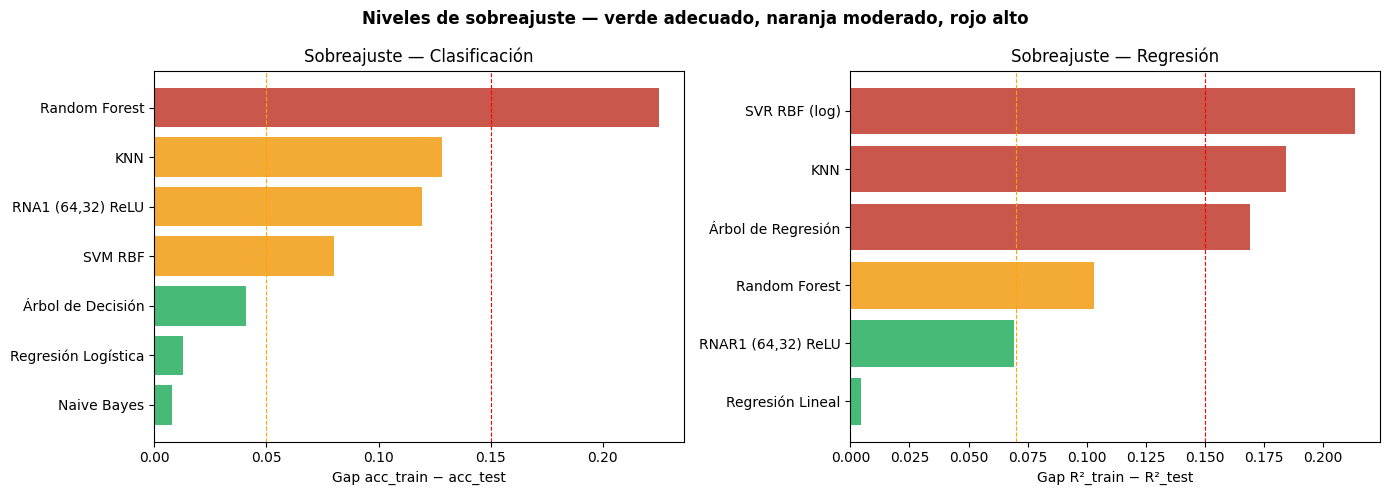

In [5]:
gap_clasificacion = pd.DataFrame({
    "Algoritmo":         ["Random Forest", "RNA1 (64,32) ReLU", "SVM RBF",
                          "Árbol de Decisión", "Regresión Logística", "KNN", "Naive Bayes"],
    "acc_train":         [0.9999, 0.8519, 0.7831, 0.7336, 0.7048, 0.7680, 0.5712],
    "acc_test":          [0.7750, 0.7323, 0.7029, 0.6927, 0.6919, 0.6395, 0.5634],
})
gap_clasificacion["gap"] = (gap_clasificacion["acc_train"] - gap_clasificacion["acc_test"]).round(4)

gap_regresion = pd.DataFrame({
    "Algoritmo":         ["Random Forest", "RNAR1 (64,32) ReLU", "Árbol de Regresión",
                          "KNN", "Regresión Lineal", "SVR RBF (log)"],
    "R²_train":          [0.9879, 0.8910, 1.0000, 0.7917, 0.5667, 0.9314],
    "R²_test":           [0.8850, 0.8219, 0.8310, 0.6076, 0.5620, 0.7180],
})
gap_regresion["gap"] = (gap_regresion["R²_train"] - gap_regresion["R²_test"]).round(4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

g_clf = gap_clasificacion.sort_values("gap", ascending=True)
col_c = ["#c0392b" if g>=0.15 else "#f39c12" if g>=0.05 else "#27ae60" for g in g_clf["gap"]]
axes[0].barh(g_clf["Algoritmo"], g_clf["gap"], color=col_c, alpha=0.85)
axes[0].set_xlabel("Gap acc_train − acc_test")
axes[0].set_title("Sobreajuste — Clasificación")
axes[0].axvline(0.05, color="orange", linestyle="--", linewidth=0.8)
axes[0].axvline(0.15, color="red",    linestyle="--", linewidth=0.8)

g_reg = gap_regresion.sort_values("gap", ascending=True)
col_r = ["#c0392b" if g>=0.15 else "#f39c12" if g>=0.07 else "#27ae60" for g in g_reg["gap"]]
axes[1].barh(g_reg["Algoritmo"], g_reg["gap"], color=col_r, alpha=0.85)
axes[1].set_xlabel("Gap R²_train − R²_test")
axes[1].set_title("Sobreajuste — Regresión")
axes[1].axvline(0.07, color="orange", linestyle="--", linewidth=0.8)
axes[1].axvline(0.15, color="red",    linestyle="--", linewidth=0.8)

plt.suptitle("Niveles de sobreajuste — verde adecuado, naranja moderado, rojo alto", fontweight="bold")
plt.tight_layout()
plt.show()


En **clasificación** los modelos más precisos son también los que más memorizan: Random Forest tiene un gap de 0.2249 (sobreajuste alto) porque sus árboles individuales alcanzan accuracy cercana a uno en entrenamiento. La RNA1 muestra sobreajuste moderado (gap=0.1196), comparable al de SVM y KNN. En el otro extremo, Naive Bayes y Regresión Logística tienen gap casi nulo, pero su bajo desempeño en prueba revela que la ausencia de sobreajuste es consecuencia de subajuste, no de buena generalización.

En **regresión** el patrón se invierte parcialmente y favorece a la red neuronal. **RNAR1 tiene el gap más bajo entre los modelos competitivos** (0.0691, ajuste adecuado), mientras Random Forest queda en sobreajuste moderado (gap=0.1029) y los demás modelos no lineales (Árbol, KNN, SVR) caen en sobreajuste alto. Es decir, RNAR1 generaliza con menor brecha que el ganador absoluto, aunque su R² de prueba quede ligeramente por debajo del de Random Forest.

Esta diferencia es importante para decisiones de despliegue: un modelo con gap alto puede degradar su desempeño cuando el mercado se desplaza (cambios estacionales, ingreso de propiedades nuevas, ajustes de tendencia). Las redes neuronales, al regularizar implícitamente mediante la activación y la inicialización aleatoria, ofrecen un comportamiento más estable a lo largo del tiempo.

## Recomendaciones para SmartStay

### Despliegue de modelos

**Para clasificar la categoría de precio:** desplegar **Random Forest** como modelo de producción. Su ventaja sobre el resto es lo suficientemente amplia (cuatro puntos porcentuales sobre la RNA y siete sobre el tercer lugar) para justificar su elección a pesar del sobreajuste alto. Reentrenar el modelo cada uno o dos meses para absorber cambios en la oferta y validar el desempeño en un set de control.

**Para predecir el precio numérico:** desplegar **Random Forest** como modelo principal y **RNAR1 como modelo de respaldo**. El uso conjunto permite dos beneficios concretos:

1. **Validación cruzada operativa.** Cuando ambos modelos coinciden dentro de un rango de tolerancia, la recomendación se entrega con alta confianza. Cuando difieren significativamente, la propiedad pasa a revisión manual.
2. **Estabilidad ante desplazamientos.** Si el mercado cambia y Random Forest empieza a degradarse, RNAR1 (con menor sobreajuste) puede mantener calidad por más tiempo, dando margen para reentrenamiento.

### Integración con el flujo operativo

Los modelos deben integrarse al sistema de recomendación de SmartStay como una capa de scoring que precede al filtrado por requerimientos del cliente. La secuencia sugerida es: (1) clasificar la propiedad por segmento, (2) estimar el precio competitivo, (3) cruzar con el presupuesto del cliente y otros filtros, (4) ordenar la lista final por una combinación de cercanía al objetivo y nivel de ocupación.

Para identificar **propiedades con baja ocupación** (objetivo de los incentivos de Airbnb), el precio estimado puede usarse como referencia: si el precio listado supera significativamente al estimado por el modelo, la propiedad probablemente está sobre-precificada y es candidata a ser priorizada en una recomendación con descuento implícito.

## Conclusiones

El proyecto demostró que es viable construir modelos de minería de datos sobre el catálogo de Airbnb que respalden las decisiones operativas de SmartStay con precisión razonable. La comparación sistemática entre siete familias de algoritmos, todas evaluadas bajo idénticas condiciones, permite responder con evidencia las preguntas de la consultoría.

**Random Forest es el algoritmo recomendado** tanto para clasificar el segmento de precio (accuracy=0.7750) como para predecir el precio numérico (R²=0.8732, RMSE=$1 525). Su capacidad para combinar muchos árboles débiles en un ensamble robusto le permite capturar las interacciones no lineales que dominan el mercado.

**Las redes neuronales son la mejor alternativa no basada en ensambles**, ocupando consistentemente el segundo lugar en ambas tareas. En regresión, además, ofrecen un nivel de sobreajuste sustancialmente menor que el resto de modelos competitivos, lo que las convierte en una herramienta de respaldo estratégica en un entorno de producción.

**Los modelos lineales y probabilísticos resultaron insuficientes** para este dominio: la relación entre los atributos de un listing y su precio es altamente interactiva, y los modelos que asumen aditividad o independencia condicional pierden mucha información. Naive Bayes, en particular, ocupó el último lugar en ambas tareas.

**El sobreajuste se gestiona, no se elimina.** Los modelos más precisos también son los que más memorizan; los que no memorizan son los que peor predicen. La decisión de despliegue requiere balancear ambos criterios, y este informe propone hacerlo mediante un esquema dual Random Forest + RNAR1 que combina precisión y estabilidad.

Con estos resultados, SmartStay queda en condiciones de profesionalizar su sistema de recomendación, aumentar la velocidad de respuesta a sus clientes y, simultáneamente, capturar los incentivos de Airbnb por activar propiedades de bajo desempeño. El siguiente paso natural es extender el análisis a la dimensión de ocupación e ingresos para cerrar el ciclo completo del negocio.